In [2]:
# Установка зависимостей
#!pip install supervision opencv-python pillow matplotlib inference-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.13.2
    Uninstalling aiohttp-3.13.2:
      Successfully uninstalled aiohttp-3.13.2


In [19]:
import cv2
import supervision as sv
import numpy as np
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient
from collections import Counter # Импортируем Counter для подсчета классов

# --- Блок 1: Подготовка данных ---

In [75]:
# Ссылка на тестовое изображение БПЛА в небе.
# В реальной системе здесь может быть подключён видеопоток.
image_url = "https://www.amic.ru/images/news/news/541742_size1.jpg?v=1"

# --- Блок 2: Инициализация клиента Roboflow ---

In [61]:
# Создается экземпляр клиента для общения с Roboflow API.
# api_url указывает на серверлесс-инфраструктуру Roboflow.
# api_key (ваш API ключ) нужен для аутентификации запроса.
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="eglFZx48BGgDdmcfqVuJ"
)

# --- Блок 3: Выполнение инференса (предсказания) ---

In [76]:
# client.run_workflow отправляет изображение на сервер для обработки.
# workspace_name="detectcorrosion-uhkuh": имя рабочего пространства пользователя.
# workflow_id="custom-workflow": конкретная версия модели/воркфлоу пользователя в котором развёрнута модель.
# images: словарь с изображениями. В данном случае передается URL.
result = client.run_workflow(
    workspace_name="detectcorrosion-uhkuh",
    workflow_id="custom-workflow-2",
    images={
        "image": image_url
    },
    use_cache=False
)

# --- Блок 4: Загрузка и конвертация изображения ---

In [77]:
# requests.get скачиваем изображение
response = requests.get(image_url)

# BytesIO превращает байты в файловый объект, понятный библиотеке PIL.
# .convert("RGB") гарантирует, что картинка будет в стандартном цветовом формате (без альфа-канала).
image = Image.open(BytesIO(response.content)).convert("RGB")

# Превращаем PIL-изображение в NumPy-массив
image_np = np.array(image)

# --- Блок 5: Обработка результатов (Парсинг) ---

In [78]:
# Результат от API приходит в виде списка словарей (по одному на каждое отправленное изображение).
# Мы отправляли одно изображение, поэтому берем result[0].
prediction_data = result[0]

# С помощью supervision обрабатываем результат присланный нам с воркфлоу Roboflow
detections = sv.Detections.from_inference(prediction_data["predictions"])

# --- Блок 6: Настройка визуализации (Аннотаторы) ---

In [79]:
box_annotator = sv.BoxAnnotator()

label_annotator = sv.LabelAnnotator()

labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections.data["class_name"], detections.confidence)
]

# --- Блок 7: Отрисовка на изображении ---

In [80]:
# Отрисовываем рамки объектов
annotated_image = box_annotator.annotate(
    scene=image_np.copy(),
    detections=detections
)

# Добавляем текстовые метки
annotated_image = label_annotator.annotate(
    scene=annotated_image,
    detections=detections,
    labels=labels
)

# --- Блок 8: Вывод результатов ---

ВНИМАНИЕ! В небе обнаружены БПЛА в количестве 1 шт.


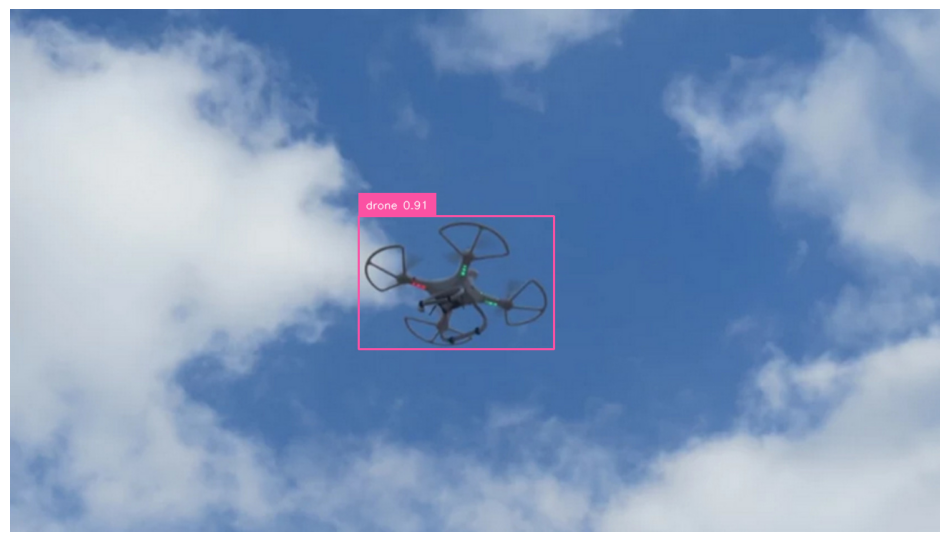

In [82]:
# Получаем общее количество обнаруженных дронов.
total_count = len(detections)

if total_count > 0:
    output_message = f"ВНИМАНИЕ! В небе обнаружены БПЛА в количестве {total_count} шт."
else:
    output_message = "БПЛА не обнаружены."

# Вывод текстовой статистики.
print(output_message)

# Используем Matplotlib для показа изображения прямо в Jupyter Notebook или окне IDE.
plt.figure(figsize=(12, 12)) # Задаем большой размер фигуры для четкости.
plt.imshow(annotated_image)
plt.axis('off') # Убираем оси координат (пиксельную линейку), чтобы было красивее.
plt.show()